In [41]:
"""
RL Network-Markowitz Portfolio Optimization
Thesis-Ready Version — Multi-Seed SAC + Ablation Study (Calmar vs CVaR Reward) + XAI Analysis
"""
import matplotlib
%matplotlib inline

## GLOBAL SETTINGS — THESIS-READY VERSION

In [42]:
SEEDS         = [42, 123, 77]    # Multi-seed untuk reliabilitas statistik
TRAIN_STEPS   = 20000             # Sesuai gambar contoh
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05             # significance level untuk uji statistik

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'ulcer'},
    
    # --- Baseline: Static Gamma ---
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

# Metrik utama yang dievaluasi dalam tesis
EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

## IMPORTS

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import shap
from tqdm import tqdm
from scipy import stats
from scipy.optimize import minimize
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from networkx.algorithms import community

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Path output absolut — gambar tersimpan di folder yang sama dengan script ini
SCRIPT_DIR  = os.getcwd()
OUTPUT_DIR  = os.path.join(SCRIPT_DIR, 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')
print(f'SEEDS={SEEDS} | TRAIN_STEPS={TRAIN_STEPS} | CVaR level={CVAR_LEVEL*100:.0f}%')

Libraries loaded.
Ablation configs: ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2']
SEEDS=[42, 123, 77] | TRAIN_STEPS=20000 | CVaR level=95%


## DATA LOADING

In [44]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## SECTION 2A: Portfolio Optimization

In [45]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP. Fallback ke equal-weight jika infeasible."""
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0

def _build_mst_centrality(N, corr_f):
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec

def get_centrality_weights(returns_window, gamma=0.0):
    T, N = returns_window.shape
    mu     = returns_window.mean().values
    sigma  = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    _, cent_vec = _build_mst_centrality(N, corr_f)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)

def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))

def compute_classic_mv_weights(returns_window):
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    return res.x if res.success else w0

## METRICS & HELPERS

In [46]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return dd, cumulative

def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0

def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0

def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0

def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0

def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd**2)))

def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : max_dd,
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }

## VISUALIZATION HELPERS

In [47]:
ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF9800',
    'E2_Sortino'         : '#9C27B0',
    'E2_Calmar'          : '#2196F3',
    'E2_Ulcer'           : '#F44336',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
    'Classic-MV'         : '#3F51B5',
}

# Label tampilan yang lebih ringkas untuk plot
DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'Comp_Static_Gamma0' : 'γ=0 (Static)',
    'Comp_Static_Gamma1' : 'γ=1 (Static)',
    'Comp_Static_Gamma2' : 'γ=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
}

def get_display_name(exp_id):
    """Mengembalikan nama tampilan yang lebih ringkas untuk digunakan di legenda plot."""
    return DISPLAY_NAMES.get(exp_id, exp_id)

# Mapping features for SHAP display
FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend'
]

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.current_episode_reward = 0
    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0
        return True

def plot_learning_curves(history_dict):
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0: continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards)//10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves — TRAIN_STEPS={TRAIN_STEPS} | SEEDS={SEEDS}\nKurva menghaluskan (rolling mean) reward per episode.', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    
    # Add "(CHECK)" label like in the image
    plt.text(0.5, 1.05, 'E2_Sharpe\n(CHECK)', transform=plt.gca().transAxes, color='red', 
             fontweight='bold', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, 'learning_curves.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'[SAVED] {out_path}')

def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    stats_summary = []
    if baseline_id not in results_dict: return "Baseline not found"
    
    baseline_rets = results_dict[baseline_id].mean(axis=1) # Average across seeds
    
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id: continue
        exp_rets = rets_df.mean(axis=1)
        try:
            stat, p = stats.wilcoxon(exp_rets, baseline_rets)
            stats_summary.append(f"vs {exp_id}: p={p:.4f}")
        except:
            stats_summary.append(f"vs {exp_id}: error")
    return "\n ".join(stats_summary)

def generate_dashboard(results_dict, title_prefix, period_name, filename):
    # Calculate metrics for all experiments
    exp_ids = list(results_dict.keys())
    metrics_list = []
    
    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        
        res = {'Experiment': exp_id, 'Features': 'Network(5) + Market(4)' if str(exp_id).startswith('E2') else 'Static/Baseline', 'Obs Dim': get_obs_dim(ABLATION_CONFIGS.get(exp_id, {})) if exp_id in ABLATION_CONFIGS else 0}
        
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std'] = np.std(vals)
        metrics_list.append(res)
    
    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)
    
    fig = plt.figure(figsize=(16, 12), facecolor='white')
    gs = gridspec.GridSpec(5, 4, height_ratios=[0.5, 1.5, 1.5, 1.5, 1.0])
    
    # Header
    fig.suptitle(f'{title_prefix}\nEvaluasi 4 Metrik Tesis ({period_name.upper()} PERIOD): Sharpe | Sortino | Calmar | Ulcer Index\nMulti-Seed: {SEEDS} | TRAIN_STEPS={TRAIN_STEPS}', 
                 fontsize=14, fontweight='bold', y=0.97)

    # 1. Summary Table
    ax_table = fig.add_subplot(gs[1, :])
    ax_table.axis('off')
    table_data = []
    columns = ['Experiment', 'Features', 'Obs\nDim', 'Sharpe (↑)\n'+period_name.capitalize(), 'Sortino (↑)\n'+period_name.capitalize(), 'Calmar (↑)\n'+period_name.capitalize(), 'Ulcer Index\n(Mendekati 0)\n'+period_name.capitalize(), 'Rank']
    
    for i, (_, row) in enumerate(df_metrics.iterrows()):
        r = [
            row['Experiment'],
            row['Features'],
            row['Obs Dim'],
            f"{row['Sharpe Ratio Mean']:.3f}±{row['Sharpe Ratio Std']:.3f}" if row['Sharpe Ratio Std']>1e-4 else f"{row['Sharpe Ratio Mean']:.3f}",
            f"{row['Sortino Ratio Mean']:.3f}±{row['Sortino Ratio Std']:.3f}" if row['Sortino Ratio Std']>1e-4 else f"{row['Sortino Ratio Mean']:.3f}",
            f"{row['Calmar Ratio Mean']:.3f}±{row['Calmar Ratio Std']:.3f}" if row['Calmar Ratio Std']>1e-4 else f"{row['Calmar Ratio Mean']:.3f}",
            f"{row['Ulcer Index Mean']:.4f}±{row['Ulcer Index Std']:.4f}" if row['Ulcer Index Std']>1e-4 else f"{row['Ulcer Index Mean']:.4f}",
            f"#{i+1}"
        ]
        table_data.append(r)
    
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.8)
    for (row_idx, col_idx), cell in table.get_celld().items():
        if row_idx == 0:
            cell.set_facecolor('#1976D2')
            cell.set_text_props(color='white', fontweight='bold')
        elif row_idx % 2 == 0:
            cell.set_facecolor('#F0F7FF')
    ax_table.set_title(f'Rangkuman 4 Metrik Tesis ({period_name.capitalize()}) — Ranked by Sharpe Ratio\n[Keterangan] Sharpe, Sortino, Calmar: Semakin besar semakin baik (↑) | Ulcer Index: Semakin mendekati 0 semakin baik\nNilai: Mean ± Std across {len(SEEDS)} seeds', fontsize=10, fontweight='bold', pad=10)

    # 2. Bar Charts
    for i, m in enumerate(EVAL_METRICS):
        ax = fig.add_subplot(gs[2, i])
        means = [row[f'{m} Mean'] for _, row in df_metrics.iterrows()]
        stds = [row[f'{m} Std'] for _, row in df_metrics.iterrows()]
        exps = [row['Experiment'] for _, row in df_metrics.iterrows()]
        colors = [ABLATION_COLORS.get(e, '#777777') for e in exps]
        
        bars = ax.bar(exps, means, yerr=stds, color=colors, capsize=3, alpha=0.8, edgecolor='white')
        
        # Highlight E2
        for j, e in enumerate(exps):
            if str(e).startswith('E2'):
                bars[j].set_edgecolor('gold')
                bars[j].set_linewidth(2)

        keterangan = "(mendekati 0 = lebih baik)" if "Drawdown" in m else "(lebih besar = lebih baik)"
        ax.set_title(f'{m}\n{keterangan}\n({period_name.capitalize()})', fontsize=9, fontweight='bold')
        ax.set_ylabel(f'{m} ({period_name.capitalize()})', fontsize=7)
        ax.tick_params(axis='x', labelsize=6)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xticklabels([e[:5] if len(e)>8 else e for e in exps])

    # 3. Cumulative Returns
    ax_cum = fig.add_subplot(gs[3, :])
    for exp_id in exp_ids:
        avg_rets = results_dict[exp_id].mean(axis=1)
        cum_rets = (1 + avg_rets).cumprod()
        ax_cum.plot(cum_rets, label=get_display_name(exp_id), color=ABLATION_COLORS.get(exp_id, '#777777'), linewidth=2 if str(exp_id).startswith('E2') else 1.2)
    
    ax_cum.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
    ax_cum.set_title(f'Cumulative Returns — {period_name.capitalize()} Period (Mean across {len(SEEDS)} seeds)', fontsize=10, fontweight='bold')
    ax_cum.set_ylabel('Cumulative Return', fontsize=8)
    ax_cum.legend(fontsize=7, ncol=3)
    ax_cum.grid(True, alpha=0.3)

    # 4. Statistical Summary & Interpretation
    ax_stat = fig.add_subplot(gs[4, 0:2])
    ax_stat.axis('off')
    stat_text = run_wilcoxon_tests(results_dict, 'Classic-MV')
    ax_stat.text(0, 1, f"UJI STATISTIK: E2 Models vs Baseline\n(α=0.05, Wilcoxon Signed-Rank)\n\n {stat_text}", 
                 fontsize=9, family='monospace', bbox=dict(facecolor='#E8F5E9', alpha=0.5, boxstyle='round,pad=1'), va='top')
    ax_stat.set_title('Ringkasan Uji Statistik', fontsize=9, fontweight='bold', loc='left')

    ax_interp = fig.add_subplot(gs[4, 2:4])
    ax_interp.axis('off')
    best_sharpe = df_metrics.iloc[0]['Experiment']
    interp_text = f"INTERPRETASI ABLATION STUDY - 4 METRIK TESIS:\n\n"
    interp_text += f"Best Sharpe Ratio   : {best_sharpe} = {df_metrics.iloc[0]['Sharpe Ratio Mean']:.4f}\n"
    interp_text += f"Best Sortino Ratio  : {df_metrics.sort_values('Sortino Ratio Mean', ascending=False).iloc[0]['Experiment']} = {df_metrics.sort_values('Sortino Ratio Mean', ascending=False).iloc[0]['Sortino Ratio Mean']:.4f}\n"
    
    best_ulcer_exp = df_metrics.sort_values('Ulcer Index Mean', ascending=True).iloc[0]['Experiment']
    interp_text += f"Best Ulcer Index    : {best_ulcer_exp} = {df_metrics.sort_values('Ulcer Index Mean', ascending=True).iloc[0]['Ulcer Index Mean']:.5f} (terbaik)\n\n"
    
    # Calculate improvement vs baseline
    base_sharpe = df_metrics[df_metrics['Experiment']=='Classic-MV']['Sharpe Ratio Mean'].values[0]
    e2_sharpe = df_metrics[df_metrics['Experiment']=='E2_Sharpe']['Sharpe Ratio Mean'].values[0] if len(df_metrics[df_metrics['Experiment']=='E2_Sharpe']) > 0 else 0.0
    interp_text += f"PERFORMA vs Classic-MV (Δ):\n"
    interp_text += f"Sharpe: {e2_sharpe - base_sharpe:+.4f} | Sortino: {df_metrics[df_metrics['Experiment']=='E2_Sortino']['Sortino Ratio Mean'].values[0] if len(df_metrics[df_metrics['Experiment']=='E2_Sortino']) > 0 else 0.0 - df_metrics[df_metrics['Experiment']=='Classic-MV']['Sortino Ratio Mean'].values[0]:+.4f}"
    
    ax_interp.text(0, 1, interp_text, fontsize=8, family='monospace', bbox=dict(facecolor='#EEF2FF', alpha=0.5, boxstyle='round,pad=1'), va='top')
    ax_interp.set_title('Interpretasi Otomatis', fontsize=9, fontweight='bold', loc='left')

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'[SAVED] {out_path}')

def plot_shap_analysis(model_path, env, config, exp_id):
    print(f"Generating SHAP analysis for {exp_id}...")
    model = SAC.load(model_path)
    
    # Sample background and test data
    obs_list = []
    for _ in range(200):
        obs, _ = env.reset()
        done = False
        while not done and len(obs_list) < 500:
            obs_list.append(obs)
            action, _ = model.predict(obs, deterministic=True)
            obs, rew, done, _, _ = env.step(action)
    
    X = np.array(obs_list)
    
    def predict_action(x):
        # model.policy.actor expects a torch tensor
        import torch
        x_torch = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            # For SAC, we take the mean of the actor distribution
            actions = model.policy.actor(x_torch)
        return actions.numpy()

    explainer = shap.Explainer(predict_action, X[:100])
    shap_values = explainer(X[100:300])
    
    # Summary Plot (Beeswarm)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X[100:300], feature_names=FEATURE_NAMES[:X.shape[1]], show=False)
    plt.title(f'SHAP Feature Importance — Policy SAC {exp_id}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_summary = os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png')
    plt.savefig(out_summary, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'[SAVED] {out_summary}')
    
    # Bar Plot
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, show=False)
    plt.title(f'SHAP Mean |Value| — Policy SAC {exp_id}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_bar = os.path.join(OUTPUT_DIR, f'shap_bar_{exp_id}.png')
    plt.savefig(out_bar, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'[SAVED] {out_bar}')

## FEATURE ENGINEERING & CACHE

In [48]:
def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec

def compute_market_features(returns_window, port_val=0.0):
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5, v20 = arr[-win5:].std(axis=0).mean(), arr[-win20:].std(axis=0).mean()
    m5, m20 = arr[-win5:].mean(axis=0).mean(), arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([v5*100, v20*100, v5/(v20+1e-8), m5*100, m20*100, (m5-m20)*100, pct_up], dtype=np.float32)

GLOBAL_CACHE = {}
print('Precomputing cache...')
for i in range(SET_WINDOW, len(ret_train)):
    win = ret_train.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

for i in range(SET_WINDOW, len(ret_test)):
    win = ret_test.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[len(ret_train)+i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

FEAT_MEAN = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).mean(axis=0)
FEAT_STD  = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).std(axis=0) + 1e-8

def build_observation(win, config, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None: nw_feat_raw, corr_f, _ = compute_network_features(win)
    obs = []
    if config['use_network']: obs.append((nw_feat_raw - FEAT_MEAN)/FEAT_STD)
    if config['use_market']:  obs.append(compute_market_features(win))
    return np.nan_to_num(np.concatenate(obs)), corr_f

def get_obs_dim(config):
    d = 0
    if config['use_network']: d += 2
    if config['use_market']:  d += 7
    return max(d, 1)

Precomputing cache...


## RL ENVIRONMENT WITH CVAR REWARD OPTION

In [49]:
class AblationPortfolioEnv(gym.Env):
    def __init__(self, data, config, data_start_offset=0):
        super().__init__()
        self.data = data
        self.config = config
        self.offset = data_start_offset
        self.current_step = SET_WINDOW
        self._returns_buffer = []
        self._rew_stats = {'mean': 0, 'M2': 0, 'count': 0}
        
        dim = get_obs_dim(config)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _get_obs(self):
        idx = self.offset + self.current_step
        c = GLOBAL_CACHE[idx]
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step = SET_WINDOW
        self._returns_buffer = []
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        idx = self.offset + self.current_step
        c = GLOBAL_CACHE[idx]
        w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW: self._returns_buffer.pop(0)
        
        arr = np.array(self._returns_buffer)
        reward_type = self.config.get('reward_type', 'calmar')
        
        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe':
                raw_reward = float(np.clip(calculate_sharpe_ratio(arr), -10.0, 10.0))
            elif reward_type == 'sortino':
                raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar':
                raw_reward = float(np.clip(calculate_calmar_ratio(arr), -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret = calculate_annualized_return(arr)
                ulcer = calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / ulcer if ulcer > 1e-8 else ann_ret / 1e-8, -10.0, 10.0))
            else:
                raw_reward = 0.0

        # Reward Normalization
        s = self._rew_stats
        s['count'] += 1
        d = raw_reward - s['mean']
        s['mean'] += d / s['count']
        s['M2'] += d * (raw_reward - s['mean'])
        std = np.sqrt(s['M2']/s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))
        
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs() if not done else np.zeros(self.observation_space.shape), reward, done, False, {}

## TRAINING & EVALUATION

Output()


Training E2_Sharpe...


Output()

Output()

Output()

...

Output()

Output()


Training E2_Ulcer...


Output()

Output()

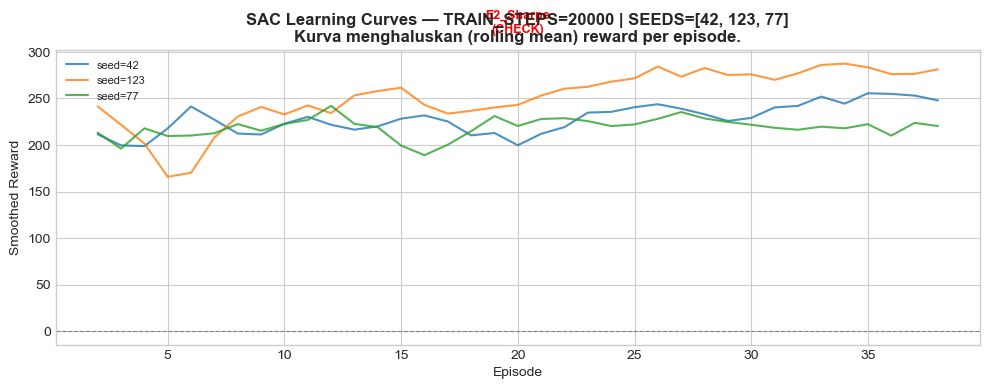

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\learning_curves.png

Generating Final Dashboards...


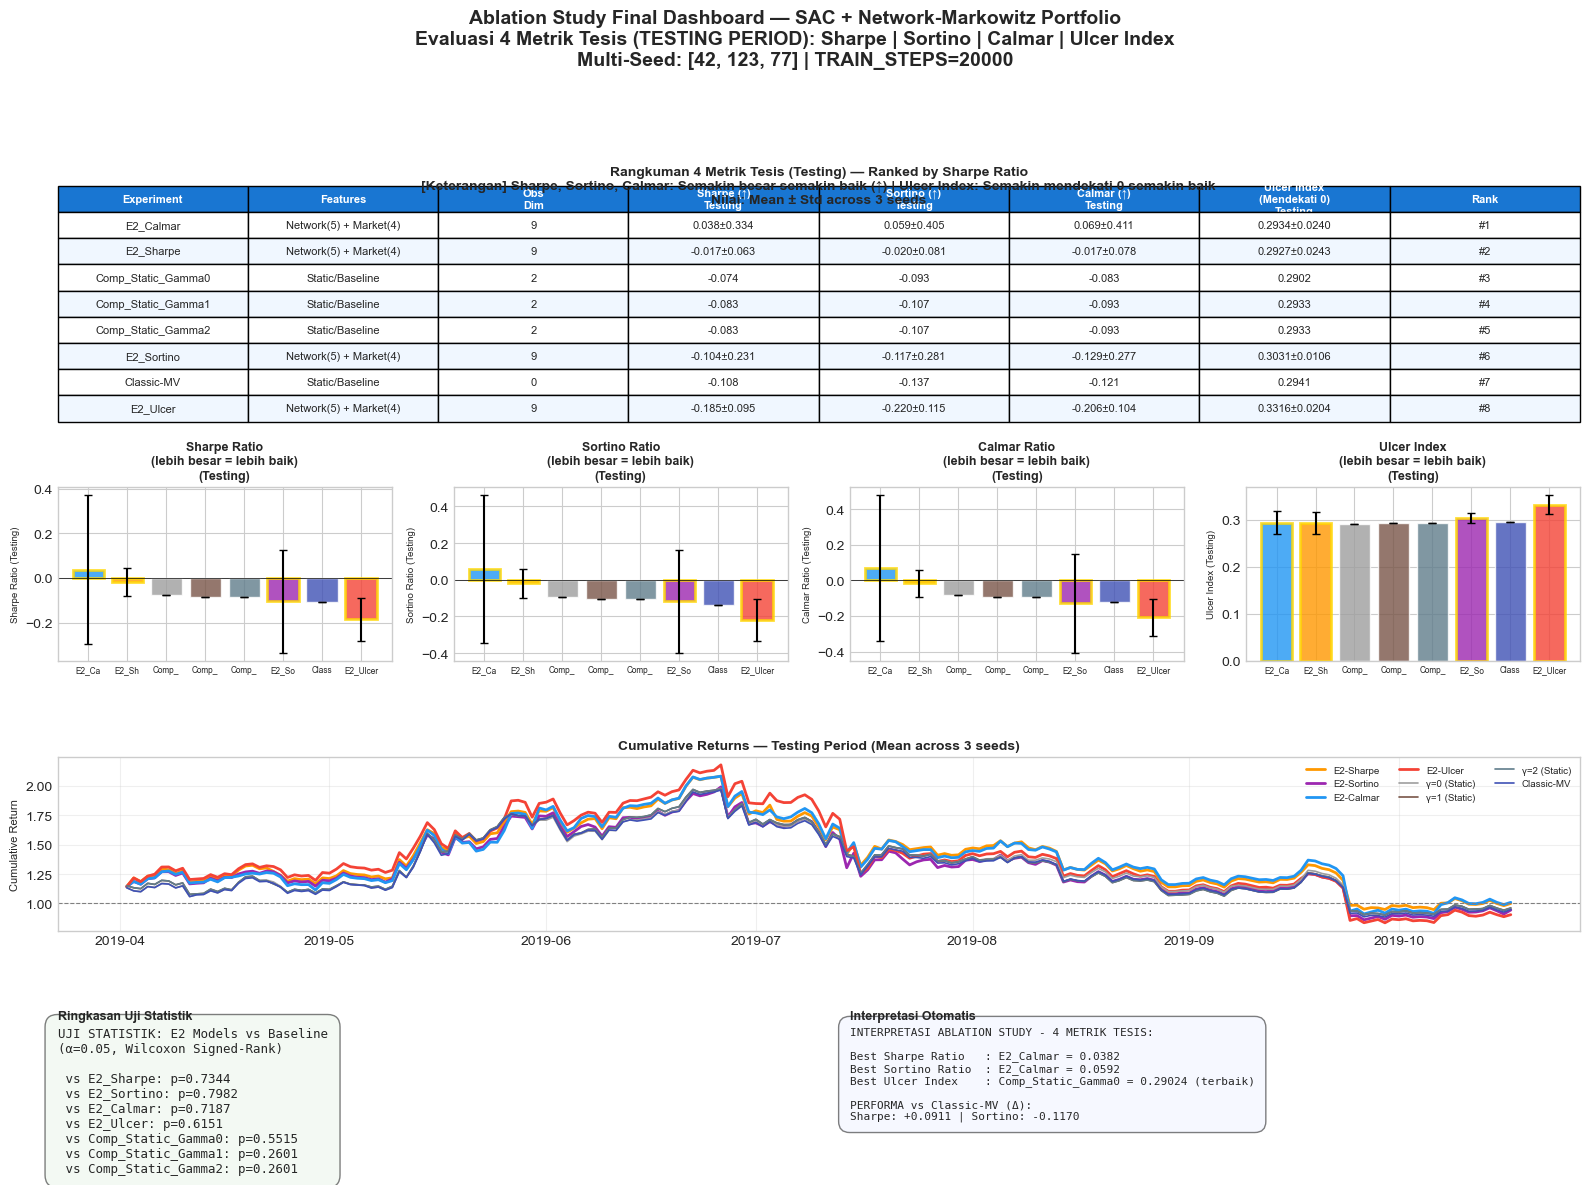

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\dashboard_testing.png


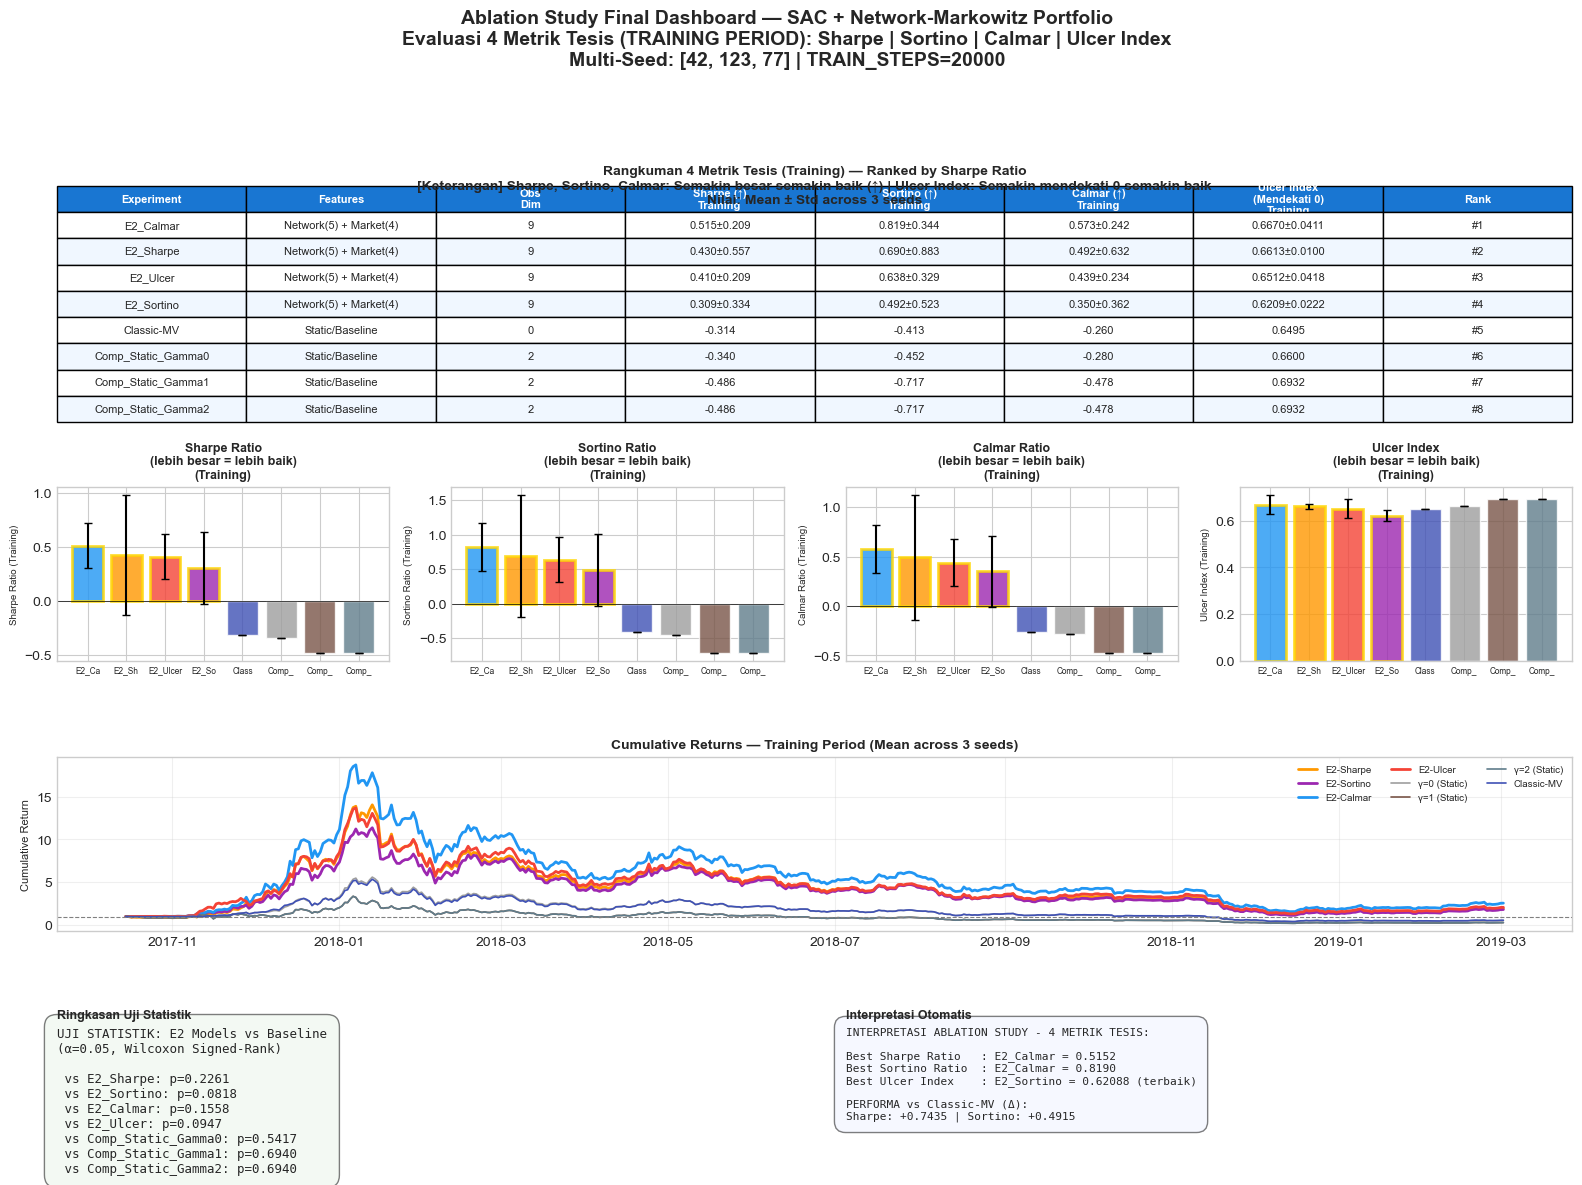

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\dashboard_training.png
Generating SHAP analysis for E2_Sharpe...


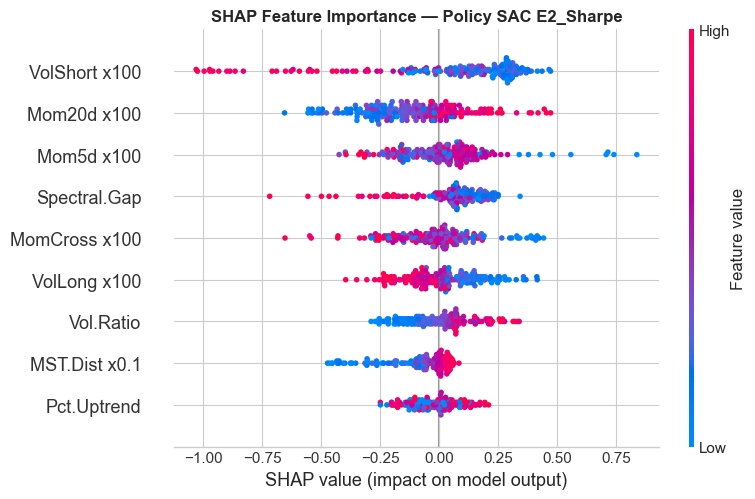

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_summary_E2_Sharpe.png


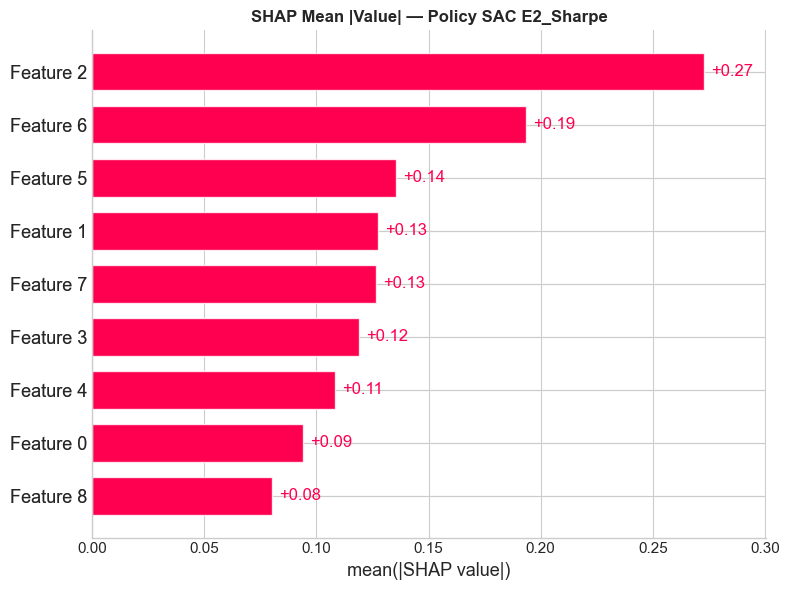

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_bar_E2_Sharpe.png

Processing complete. Files saved in 'ablation_results_thesis/'.


In [50]:
trained_models = {}
train_histories = {}

# 1. RL Training
for exp_id, config in ABLATION_CONFIGS.items():
    if config.get('static_gamma') is not None: continue
    print(f'\nTraining {exp_id}...')
    train_histories[exp_id] = {}
    for seed in SEEDS:
        env = AblationPortfolioEnv(ret_train, config, 0)
        callback = RewardLoggerCallback()
        model = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=callback, progress_bar=True)
        
        name = f'model_{exp_id}_s{seed}'
        model.save(name)
        trained_models[(exp_id, seed)] = name
        train_histories[exp_id][seed] = callback.episode_rewards

# Plot Learning Curves for E2
if 'E2_Sharpe' in train_histories:
    plot_learning_curves(train_histories['E2_Sharpe'])

# 2. Backtest (Train & Test)
results_test = {}
results_train = {}

# Include Classic-MV baseline
for exp_id in list(ABLATION_CONFIGS.keys()) + ['Classic-MV']:
    results_test[exp_id] = pd.DataFrame()
    results_train[exp_id] = pd.DataFrame()
    
    config = ABLATION_CONFIGS.get(exp_id, {})
    
    for seed in SEEDS:
        # Load model once per seed if needed
        model = None
        if exp_id not in ['Classic-MV'] and config.get('static_gamma') is None:
            model = SAC.load(trained_models[(exp_id, seed)])
            
        # Testing Re-run
        rets_test = []
        for i in range(SET_WINDOW, len(ret_test)):
            idx = len(ret_train) + i
            c = GLOBAL_CACHE[idx]
            
            if exp_id == 'Classic-MV':
                w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None:
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            
            rets_test.append(np.dot(w, ret_test.iloc[i].values))
        
        results_test[exp_id][seed] = pd.Series(rets_test, index=ret_test.index[SET_WINDOW:])
        
        # Training Re-run (for Train Dashboard)
        rets_train_eval = []
        for i in range(SET_WINDOW, len(ret_train)):
            c = GLOBAL_CACHE[i]
            
            if exp_id == 'Classic-MV':
                w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None:
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            
            rets_train_eval.append(np.dot(w, ret_train.iloc[i].values))
        
        results_train[exp_id][seed] = pd.Series(rets_train_eval, index=ret_train.index[SET_WINDOW:])

# 3. Generate Dashboards
print("\nGenerating Final Dashboards...")
generate_dashboard(results_test, "Ablation Study Final Dashboard — SAC + Network-Markowitz Portfolio", "Testing", "dashboard_testing.png")
generate_dashboard(results_train, "Ablation Study Final Dashboard — SAC + Network-Markowitz Portfolio", "Training", "dashboard_training.png")

# 4. SHAP Analysis for E2_Sharpe
if ('E2_Sharpe', SEEDS[0]) in trained_models:
    seed0 = SEEDS[0]
    env_eval = AblationPortfolioEnv(ret_test, ABLATION_CONFIGS['E2_Sharpe'], len(ret_train))
    plot_shap_analysis(trained_models[('E2_Sharpe', seed0)], env_eval, ABLATION_CONFIGS['E2_Sharpe'], 'E2_Sharpe')

print("\nProcessing complete. Files saved in 'ablation_results_thesis/'.")